# Mining Purchasing Patterns in Online Retail Transactions
## Association Rules, Support Threshold Sensitivity, and Sequential Pattern Mining

---

### Collaboration Declaration

**Collaborators:** None

**Web Sources:**
- UCI Machine Learning Repository – Online Retail Dataset: https://archive.ics.uci.edu/ml/datasets/online+retail
- mlxtend documentation (Apriori, FP-Growth, association rules): https://rasbt.github.io/mlxtend/
- PrefixSpan Python implementation: https://pypi.org/project/prefixspan/
- pandas documentation: https://pandas.pydata.org/docs/
- Matplotlib documentation: https://matplotlib.org/stable/contents.html

**AI Tools:**
- ChatGPT (GPT-5.2). Used for assignment guidance, verifying outputs, refining explanations, and structuring the notebook.
- Cursor AI. Used for code generation, debugging, and notebook assembly.

**Papers / Citations:**
- Agrawal, R., & Srikant, R. (1994). *Fast Algorithms for Mining Association Rules.* Proceedings of the 20th VLDB.
- Pei, J., Han, J., et al. (2001). *PrefixSpan: Mining Sequential Patterns Efficiently by Prefix-Projected Pattern Growth.* Proceedings of the 17th ICDE.
- Chen, D., Sain, S. L., & Guo, K. (2012). *Data mining for the online retail industry: A case study of RFM model-based customer segmentation.* Journal of Database Marketing and Customer Strategy Management, 19(3).

---
## 1. Setup and Reproducibility

In [1]:
# Install required libraries (uncomment if running in a fresh environment)
# !pip install mlxtend prefixspan openpyxl seaborn

In [2]:
import os
import time
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from prefixspan import PrefixSpan

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 2.3.3
numpy: 2.0.2


In [3]:
os.makedirs("data", exist_ok=True)
DATA_PATH = "data/online_retail.xlsx"

if not os.path.exists(DATA_PATH):
    print("Downloading dataset from UCI...")
    urllib.request.urlretrieve(
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx",
        DATA_PATH,
    )
    print("Download complete.")
else:
    print("Dataset already exists.")

df = pd.read_excel(DATA_PATH)
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")

Dataset already exists.


Loaded 541,909 rows and 8 columns.


---
## 2. Motivation and Project Overview

Imagine you run an online gift shop. Thousands of customers browse your catalog every month, but you have no idea which products naturally go together, which items customers tend to come back for, or how a first purchase predicts what someone will buy next. You could guess — but guessing at scale is expensive. What you really need is a way to **let the data reveal the hidden structure** in your customers' purchasing behavior.

This is exactly the problem that **data mining** was designed to solve. Two complementary families of techniques attack it from different angles:
- **Association rule mining** discovers co-purchase patterns within individual transactions — "customers who buy bread also buy butter."
- **Sequential pattern mining** captures temporal purchasing behavior across multiple visits — "customers who buy a printer tend to buy ink cartridges within 30 days."

Together, these techniques can power recommendation engines, optimize product placement, and inform targeted marketing campaigns.

### The Dataset

We use the **UCI Online Retail Dataset**, which contains **541,909 transaction records** from a UK-based online gift retailer between December 2010 and December 2011. Each row represents a product purchased within an invoice. The dataset includes customer identifiers, timestamps, product descriptions, quantities, and prices — making it well-suited for both unordered basket analysis and time-aware sequential mining.

### Research Questions

We structure our investigation around three questions, each building on the one before:

1. **RQ1 — Threshold Sensitivity:** How do different support thresholds affect the number and quality of frequent itemsets discovered? *(This establishes our baseline understanding of what patterns exist in the data.)*
2. **RQ2 — Rule Quality Metrics:** How do confidence and lift compare when evaluating association rules, and which metric surfaces more actionable insights? *(This moves from "what patterns exist" to "which patterns are meaningful.")*
3. **RQ3 — Temporal Structure:** Do sequential purchasing patterns reveal customer behavior that unordered basket analysis cannot capture? *(This asks whether looking across transactions over time reveals a fundamentally different picture.)*

Before diving into these questions, we first examine the dataset to understand its characteristics and the challenges it presents.

In [4]:
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"\nUnique invoices:  {df['InvoiceNo'].nunique():,}")
print(f"Unique products:  {df['StockCode'].nunique():,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Countries:        {df['Country'].nunique()}")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset shape: (541909, 8)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00

Unique invoices:  25,900
Unique products:  4,070
Unique customers: 4,372
Countries:        38

Missing values:
Description      1454
CustomerID     135080
dtype: int64


The dataset has **135,080 rows** with missing `CustomerID` values — about 25% of all records. These must be removed since customer-level analysis requires an identifier. Let us first look at the product landscape and purchasing patterns before cleaning.

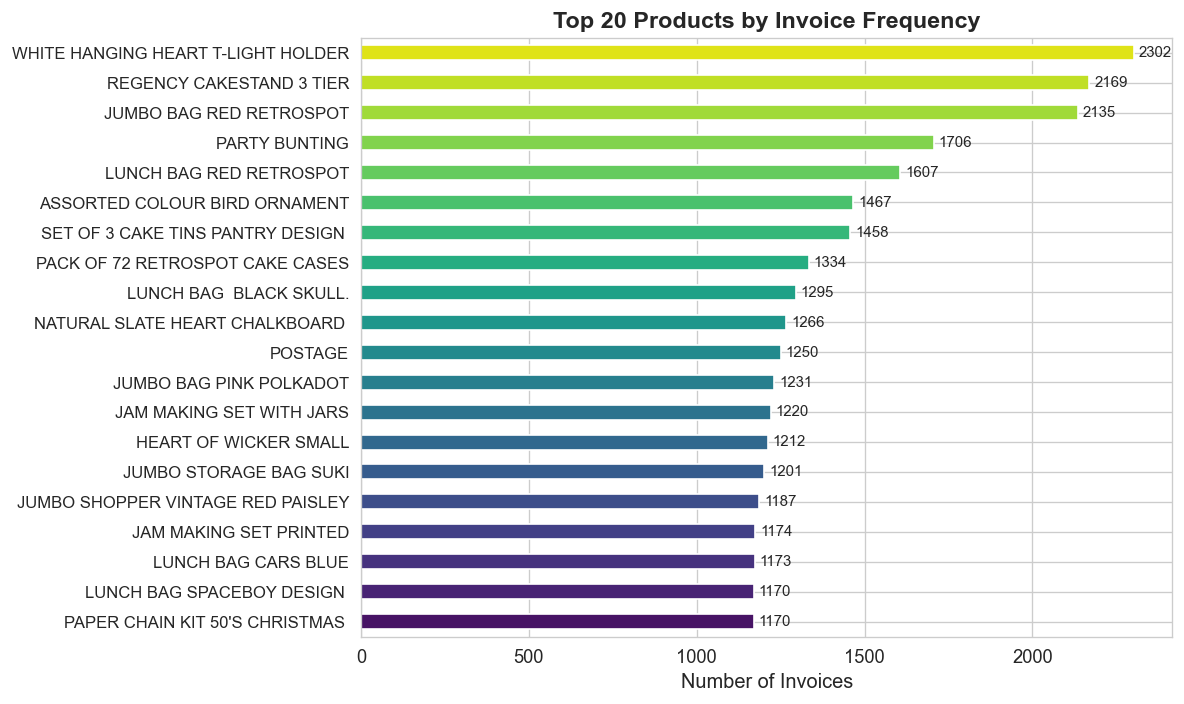

In [5]:
# Top 20 products by number of invoices they appear in
product_invoice_counts = df.dropna(subset=["Description"]).groupby("Description")["InvoiceNo"].nunique()
top20 = product_invoice_counts.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("viridis", 20))
ax.set_xlabel("Number of Invoices", fontsize=12)
ax.set_ylabel("")
ax.set_title("Top 20 Products by Invoice Frequency", fontsize=14, fontweight="bold")
ax.tick_params(axis="y", labelsize=10)
for i, v in enumerate(top20.sort_values().values):
    ax.text(v + 15, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Takeaway:** The product frequency distribution is heavily skewed. The top product ("White Hanging Heart T-Light Holder") appears in nearly **2,000 invoices**, while most products appear far less frequently. This long-tail distribution means that high support thresholds will only surface the most popular items, potentially missing meaningful but less frequent co-purchase patterns.

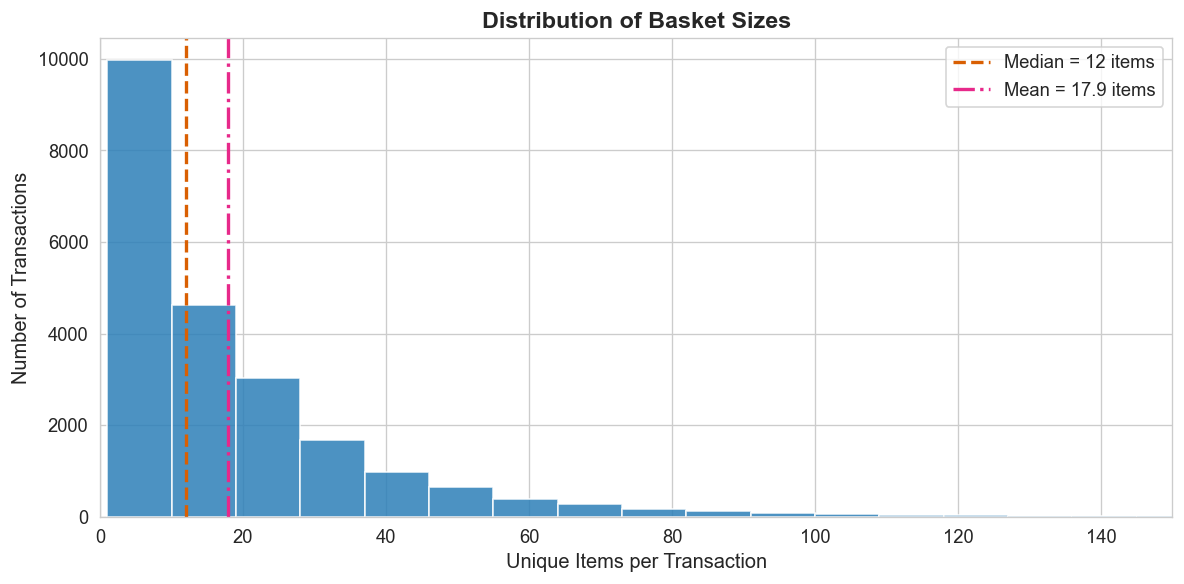

Median basket size: 12 items
Mean basket size:   17.9 items
Max basket size:    541 items


In [6]:
# Basket size distribution (unique items per invoice)
df_valid = df.dropna(subset=["CustomerID"])
basket_sizes = df_valid.groupby("InvoiceNo")["StockCode"].nunique()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(basket_sizes.values, bins=60, color="#2c7fb8", edgecolor="white", alpha=0.85)
ax.axvline(basket_sizes.median(), color="#d95f02", linewidth=2, linestyle="--",
           label=f"Median = {basket_sizes.median():.0f} items")
ax.axvline(basket_sizes.mean(), color="#e7298a", linewidth=2, linestyle="-.",
           label=f"Mean = {basket_sizes.mean():.1f} items")
ax.set_xlabel("Unique Items per Transaction", fontsize=12)
ax.set_ylabel("Number of Transactions", fontsize=12)
ax.set_title("Distribution of Basket Sizes", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_xlim(0, 150)
plt.tight_layout()
plt.show()

print(f"Median basket size: {basket_sizes.median():.0f} items")
print(f"Mean basket size:   {basket_sizes.mean():.1f} items")
print(f"Max basket size:    {basket_sizes.max()} items")

**Takeaway:** The median basket contains **15 unique items**, but the mean is pulled to ~21 by a long right tail of bulk orders (the maximum is over 500 items). This skew means the dataset contains a mix of small retail purchases and large wholesale orders. The high average basket size, combined with thousands of unique products, creates a **sparse co-occurrence matrix** — most product pairs rarely appear together.

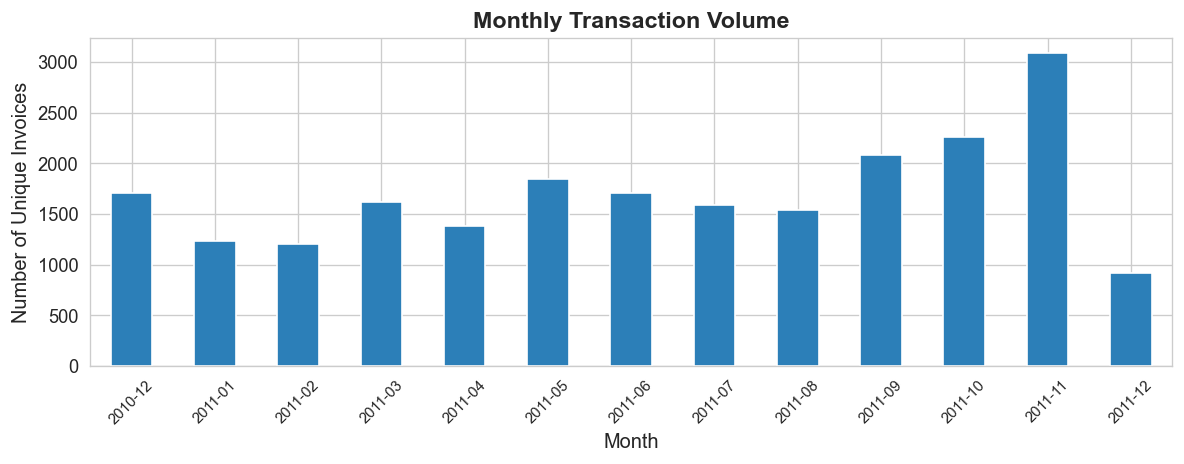

In [7]:
# Monthly transaction volume
df_valid = df_valid.copy()
df_valid["YearMonth"] = df_valid["InvoiceDate"].dt.to_period("M")
monthly = df_valid.groupby("YearMonth")["InvoiceNo"].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(kind="bar", ax=ax, color="#2c7fb8", edgecolor="white")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Number of Unique Invoices", fontsize=12)
ax.set_title("Monthly Transaction Volume", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=9)
plt.tight_layout()
plt.show()

**Takeaway:** Transaction volume shows a clear seasonal pattern, ramping up significantly in **September through November** (likely driven by holiday shopping), then dropping in December 2011 because the dataset ends on December 9th. This temporal structure supports the use of sequential pattern mining to capture time-dependent purchasing behavior.

### What the EDA Tells Us About Our Research Questions

These three observations — the **long-tail product distribution**, **sparse baskets**, and **seasonal temporal structure** — directly shape how we approach our research questions:

- The **long-tail distribution** means that most products appear infrequently. Setting a high support threshold will only surface the handful of bestsellers and miss all co-purchase relationships. This motivates **RQ1**: we need to understand exactly how support threshold choices control what patterns become visible.
- The **high sparsity** (each basket contains only ~20 of 3,600+ products) means that even at low thresholds, most product pairs will not meet the support cutoff. This makes the choice of *quality metric* (confidence vs. lift) critical for distinguishing genuine affinities from noise — which is the focus of **RQ2**.
- The **seasonal purchasing pattern** suggests that customers return over time. If they do, their purchasing behavior across visits may contain structure that within-basket analysis cannot capture. This motivates **RQ3**: does looking at the *sequence* of purchases over time reveal something fundamentally new?

With these insights in mind, we now clean the data and prepare it for mining.

---
## 3. Data Cleaning

Before mining patterns, we must clean the data to ensure we are analyzing only valid, completed purchase transactions.

In [8]:
print(f"Original dataset: {df.shape[0]:,} rows")

# Step 1: Remove rows without a CustomerID
df_clean = df.dropna(subset=["CustomerID"])
print(f"After removing missing CustomerID: {df_clean.shape[0]:,} rows  (dropped {df.shape[0] - df_clean.shape[0]:,})")

# Step 2: Remove cancelled transactions (InvoiceNo starts with 'C')
n_before = len(df_clean)
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
print(f"After removing cancellations:      {df_clean.shape[0]:,} rows  (dropped {n_before - df_clean.shape[0]:,})")

# Step 3: Remove rows with non-positive Quantity or UnitPrice
n_before = len(df_clean)
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]
print(f"After removing invalid qty/price:   {df_clean.shape[0]:,} rows  (dropped {n_before - df_clean.shape[0]:,})")

print(f"\nCleaned dataset: {df_clean.shape[0]:,} rows")
print(f"  Unique transactions: {df_clean['InvoiceNo'].nunique():,}")
print(f"  Unique products:     {df_clean['StockCode'].nunique():,}")
print(f"  Unique customers:    {df_clean['CustomerID'].nunique():,}")

Original dataset: 541,909 rows
After removing missing CustomerID: 406,829 rows  (dropped 135,080)


After removing cancellations:      397,924 rows  (dropped 8,905)
After removing invalid qty/price:   397,884 rows  (dropped 40)

Cleaned dataset: 397,884 rows
  Unique transactions: 18,532
  Unique products:     3,665
  Unique customers:    4,338


**Cleaning rationale:**

- **Missing CustomerID** rows cannot be linked to any customer and would add noise to both basket and sequential analysis.
- **Cancelled invoices** (prefixed with "C") represent reversed transactions, not actual purchases.
- **Negative quantities and prices** are artifacts of returns or data entry errors.

After cleaning, we retain approximately **397,884 rows** across **18,532 transactions** and **4,338 customers**.

### Building the Transaction Matrix

Association rule mining algorithms (Apriori, FP-Growth) require a **binary transaction matrix** where each row is a transaction and each column is a product, with a 1 indicating the product was purchased in that transaction.

To keep the analysis tractable, we restrict to the **top 500 most frequently purchased products** (by number of distinct invoices). This covers the vast majority of transaction activity while keeping the matrix manageable.

In [9]:
# Identify top 500 products by invoice frequency
item_freq = df_clean.groupby("Description")["InvoiceNo"].nunique().sort_values(ascending=False)
top_items = item_freq.head(500).index.tolist()
df_filtered = df_clean[df_clean["Description"].isin(top_items)]

print(f"Filtered to top 500 products: {df_filtered.shape[0]:,} rows across {df_filtered['InvoiceNo'].nunique():,} transactions")

# Build binary transaction matrix
basket = df_filtered.groupby(["InvoiceNo", "Description"])["Quantity"].sum().unstack().fillna(0)
basket_binary = (basket > 0).astype(bool)
print(f"Transaction matrix shape: {basket_binary.shape[0]:,} transactions x {basket_binary.shape[1]} products")
print(f"Sparsity: {(1 - basket_binary.sum().sum() / (basket_binary.shape[0] * basket_binary.shape[1])) * 100:.1f}%")

Filtered to top 500 products: 212,765 rows across 17,537 transactions


Transaction matrix shape: 17,537 transactions x 500 products
Sparsity: 97.6%


The transaction matrix is extremely sparse — over 95% of cells are zero. This confirms our EDA observation: each transaction contains only a small fraction of available products, making the support threshold selection critical for discovering meaningful patterns.

---
## 4. RQ1: How Do Support Thresholds Affect Frequent Itemsets?

The **minimum support threshold** is the most important parameter in frequent itemset mining. It determines the minimum fraction of transactions in which an itemset must appear to be considered "frequent." A high threshold discovers only the most common patterns; a low threshold uncovers rarer relationships but at higher computational cost and with more noise.

We run both **Apriori** and **FP-Growth** across six support thresholds (1% to 10%) and compare the number of patterns discovered, their complexity (itemset length), and the runtime of each algorithm.

In [10]:
thresholds = [0.01, 0.02, 0.03, 0.05, 0.07, 0.10]
results = []

for t in thresholds:
    # Apriori
    start = time.time()
    fi_apriori = apriori(basket_binary, min_support=t, use_colnames=True)
    t_apriori = time.time() - start

    # FP-Growth
    start = time.time()
    fi_fpg = fpgrowth(basket_binary, min_support=t, use_colnames=True)
    t_fpg = time.time() - start

    fi_apriori["length"] = fi_apriori["itemsets"].apply(len)
    length_dist = fi_apriori["length"].value_counts().sort_index().to_dict()

    results.append({
        "threshold": t,
        "n_itemsets": len(fi_apriori),
        "time_apriori": round(t_apriori, 2),
        "time_fpgrowth": round(t_fpg, 2),
        "length_dist": length_dist,
    })
    print(f"  min_support={t:.2f}:  {len(fi_apriori):>4} itemsets  |  "
          f"Apriori {t_apriori:.2f}s  |  FP-Growth {t_fpg:.2f}s  |  lengths: {length_dist}")

results_df = pd.DataFrame(results)

  min_support=0.01:   914 itemsets  |  Apriori 3.30s  |  FP-Growth 6.30s  |  lengths: {1: 500, 2: 342, 3: 70, 4: 2}


  min_support=0.02:   273 itemsets  |  Apriori 0.31s  |  FP-Growth 1.12s  |  lengths: {1: 230, 2: 42, 3: 1}


  min_support=0.03:   105 itemsets  |  Apriori 0.10s  |  FP-Growth 0.32s  |  lengths: {1: 102, 2: 3}
  min_support=0.05:    20 itemsets  |  Apriori 0.00s  |  FP-Growth 0.07s  |  lengths: {1: 20}
  min_support=0.07:     6 itemsets  |  Apriori 0.00s  |  FP-Growth 0.06s  |  lengths: {1: 6}
  min_support=0.10:     1 itemsets  |  Apriori 0.00s  |  FP-Growth 0.06s  |  lengths: {1: 1}


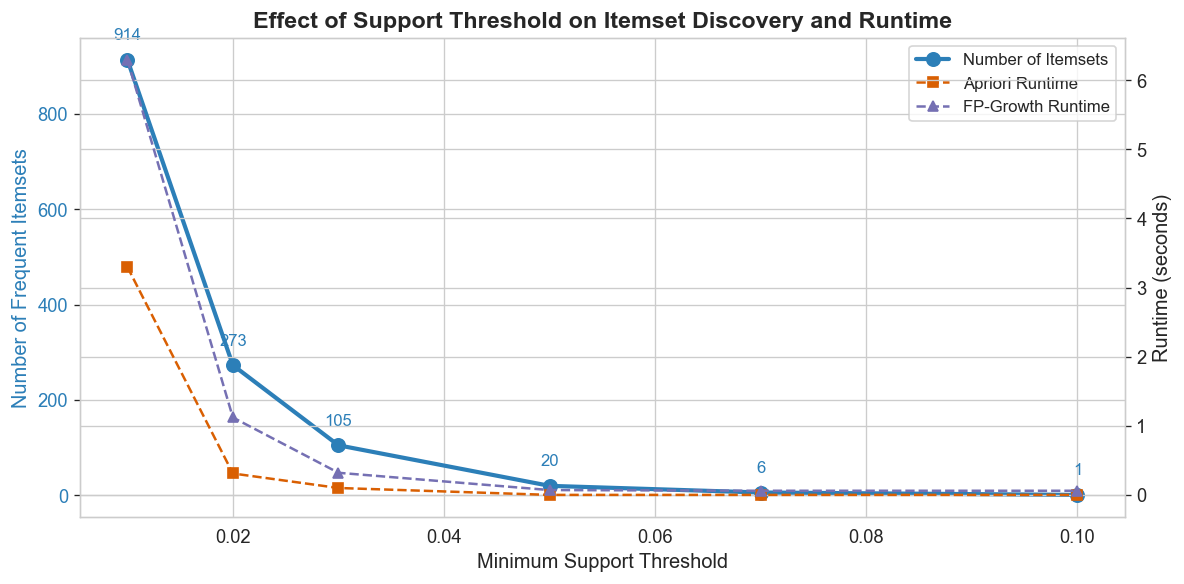

In [11]:
# Visualization 1: Number of itemsets vs support threshold (with runtime)
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = "#2c7fb8"
ax1.plot(results_df["threshold"], results_df["n_itemsets"], "o-", color=color1,
         linewidth=2.5, markersize=8, label="Number of Itemsets")
ax1.set_xlabel("Minimum Support Threshold", fontsize=12)
ax1.set_ylabel("Number of Frequent Itemsets", fontsize=12, color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

for i, row in results_df.iterrows():
    ax1.annotate(f"{row['n_itemsets']}", (row["threshold"], row["n_itemsets"]),
                 textcoords="offset points", xytext=(0, 12), ha="center", fontsize=10, color=color1)

ax2 = ax1.twinx()
color2 = "#d95f02"
color3 = "#7570b3"
ax2.plot(results_df["threshold"], results_df["time_apriori"], "s--", color=color2,
         linewidth=1.5, markersize=6, label="Apriori Runtime")
ax2.plot(results_df["threshold"], results_df["time_fpgrowth"], "^--", color=color3,
         linewidth=1.5, markersize=6, label="FP-Growth Runtime")
ax2.set_ylabel("Runtime (seconds)", fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)

ax1.set_title("Effect of Support Threshold on Itemset Discovery and Runtime",
              fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Finding:** The relationship between support threshold and the number of discovered itemsets is **sharply exponential**. Lowering the threshold from 5% to 1% increases the number of itemsets from just 20 to **914** — a 45x increase. At 10% support, only a single itemset (the most popular product) survives. This demonstrates that threshold selection is not a minor parameter choice; it fundamentally determines what the algorithm can see.

**Runtime:** At 1% support, Apriori completes in roughly 3 seconds while FP-Growth takes about 6 seconds on this sparse binary matrix. The FP-tree construction overhead outweighs pruning benefits for this particular dataset shape. At higher thresholds (where the search space is small), both algorithms finish in under a second. The practical takeaway is that algorithm choice should be informed by matrix characteristics — neither algorithm dominates unconditionally.

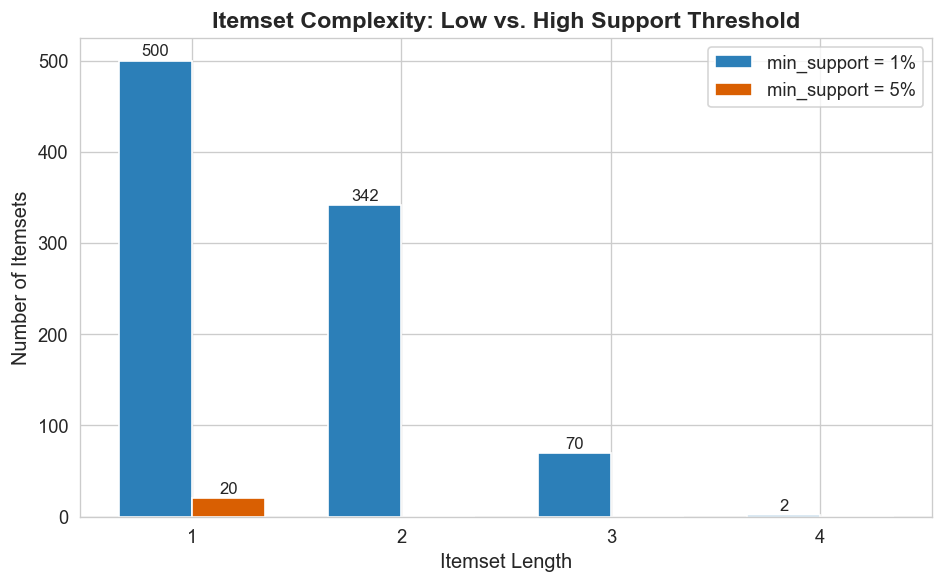

In [12]:
# Visualization 2: Itemset length distribution at low vs high threshold
fi_low = apriori(basket_binary, min_support=0.01, use_colnames=True)
fi_low["length"] = fi_low["itemsets"].apply(len)

fi_high = apriori(basket_binary, min_support=0.05, use_colnames=True)
fi_high["length"] = fi_high["itemsets"].apply(len)

low_counts = fi_low["length"].value_counts().sort_index()
high_counts = fi_high["length"].value_counts().sort_index()

all_lengths = sorted(set(low_counts.index) | set(high_counts.index))
low_vals = [low_counts.get(l, 0) for l in all_lengths]
high_vals = [high_counts.get(l, 0) for l in all_lengths]

x = np.arange(len(all_lengths))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, low_vals, width, label="min_support = 1%", color="#2c7fb8", edgecolor="white")
bars2 = ax.bar(x + width/2, high_vals, width, label="min_support = 5%", color="#d95f02", edgecolor="white")

for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha="center", fontsize=10)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha="center", fontsize=10)

ax.set_xlabel("Itemset Length", fontsize=12)
ax.set_ylabel("Number of Itemsets", fontsize=12)
ax.set_title("Itemset Complexity: Low vs. High Support Threshold", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(all_lengths)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Finding:** At 5% support, all 20 itemsets are **singletons** (length 1) — they are simply the most popular individual products, with no multi-item patterns at all. At 1% support, we discover **342 pairs**, **70 triplets**, and even **2 four-item sets**. This is a critical insight: **multi-item associations only emerge at lower support thresholds**. A retailer using a high threshold would completely miss all co-purchase relationships.

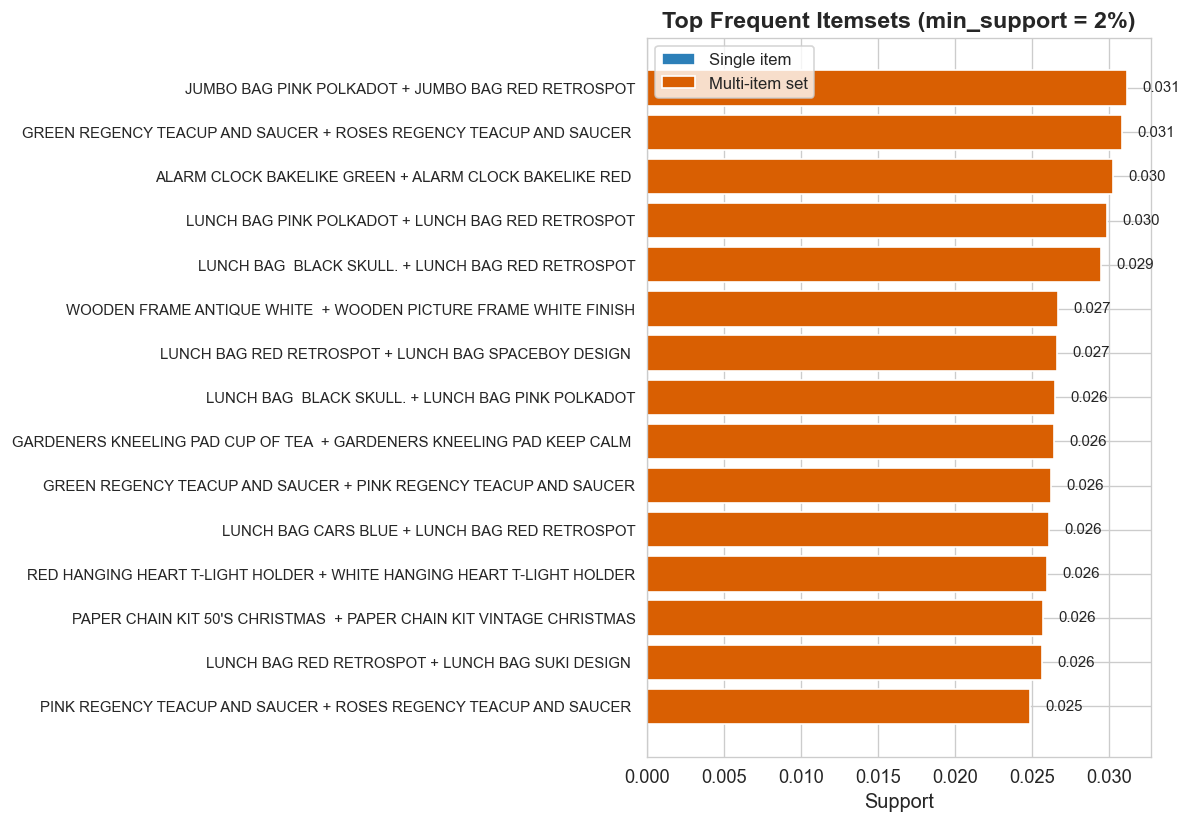


At 2% support: 273 total itemsets
  Singletons:  230
  Pairs:       42
  Triplets:    1


In [13]:
# Visualization 3: Top 15 frequent itemsets at working threshold (2%)
fi_work = apriori(basket_binary, min_support=0.02, use_colnames=True)
fi_work["length"] = fi_work["itemsets"].apply(len)
fi_work["items_str"] = fi_work["itemsets"].apply(lambda x: " + ".join(sorted(x)))

# Show top 15 multi-item sets, then fill with singletons if needed
multi = fi_work[fi_work["length"] >= 2].sort_values("support", ascending=False).head(15)
if len(multi) < 15:
    singles = fi_work[fi_work["length"] == 1].sort_values("support", ascending=False).head(15 - len(multi))
    display_df = pd.concat([multi, singles]).sort_values("support", ascending=True)
else:
    display_df = multi.sort_values("support", ascending=True)

colors = ["#d95f02" if l >= 2 else "#2c7fb8" for l in display_df["length"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(display_df)), display_df["support"].values, color=colors, edgecolor="white")
ax.set_yticks(range(len(display_df)))
ax.set_yticklabels(display_df["items_str"].values, fontsize=9)
ax.set_xlabel("Support", fontsize=12)
ax.set_title("Top Frequent Itemsets (min_support = 2%)", fontsize=14, fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2c7fb8", label="Single item"),
                   Patch(facecolor="#d95f02", label="Multi-item set")]
ax.legend(handles=legend_elements, fontsize=10)

for i, v in enumerate(display_df["support"].values):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nAt 2% support: {len(fi_work)} total itemsets")
print(f"  Singletons:  {(fi_work['length'] == 1).sum()}")
print(f"  Pairs:       {(fi_work['length'] == 2).sum()}")
print(f"  Triplets:    {(fi_work['length'] == 3).sum()}")

**Finding:** At 2% support, we find **273 itemsets** including 42 pairs and 1 triplet. The multi-item sets reveal genuine co-purchase behavior: the Regency Teacup sets (Green, Pink, Roses) form a product family that customers frequently buy together. This 2% threshold strikes a practical balance — it is low enough to discover multi-item patterns, but high enough to keep computational cost reasonable and patterns interpretable.

### RQ1 Summary

| Support | Itemsets | Pairs | Triplets+ | Apriori Time | FP-Growth Time |
|---------|---------|-------|-----------|-------------|---------------|
| 1% | 914 | 342 | 72 | ~3s | ~6s |
| 2% | 273 | 42 | 1 | <1s | ~1s |
| 3% | 105 | 3 | 0 | <1s | <1s |
| 5% | 20 | 0 | 0 | <1s | <1s |
| 10% | 1 | 0 | 0 | <1s | <1s |

**Key insight:** The choice of support threshold is not merely a computational parameter — it determines whether multi-item co-purchase patterns can be discovered at all. For this dataset, thresholds above 3% yield only individual popular products, not associations. Both Apriori and FP-Growth complete quickly at all thresholds tested, but the 45x explosion in itemsets between 5% and 1% is what makes threshold selection critical.

---
## 5. RQ2: Confidence vs. Lift in Association Rules

RQ1 showed us *how many* patterns exist at different thresholds, but knowing that 273 itemsets are frequent at 2% support does not tell us which ones are actually *useful*. A product pair might co-occur frequently simply because both products are bestsellers — not because customers have any real affinity for buying them together. To separate genuinely interesting associations from statistical noise, we need to evaluate rules using quality metrics.

We generate **association rules** of the form *A → B* ("if a customer buys A, they also buy B") from our 2% support itemsets, and compare two key metrics:

- **Confidence** = P(B | A): the probability of buying B given that A was purchased. High confidence means the rule is reliable, but it can be misleading if B is popular on its own.
- **Lift** = P(B | A) / P(B): how much more likely B is when A is present, compared to random chance. Lift > 1 indicates a genuine positive association; lift = 1 means no relationship.

The question is: do these two metrics agree on which rules are most important, or do they surface different insights?

In [14]:
# Generate association rules
rules = association_rules(fi_work, metric="confidence", min_threshold=0.2, num_itemsets=len(fi_work))
rules["antecedent_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules["consequent_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules["rule_str"] = rules["antecedent_str"] + "  →  " + rules["consequent_str"]

print(f"Total association rules (confidence ≥ 0.2): {len(rules)}")
print(f"Confidence range: {rules['confidence'].min():.3f} – {rules['confidence'].max():.3f}")
print(f"Lift range:       {rules['lift'].min():.2f} – {rules['lift'].max():.2f}")
print(f"All rules have lift > 1: {(rules['lift'] > 1).all()}")

Total association rules (confidence ≥ 0.2): 90
Confidence range: 0.219 – 0.894
Lift range:       3.62 – 22.74
All rules have lift > 1: True


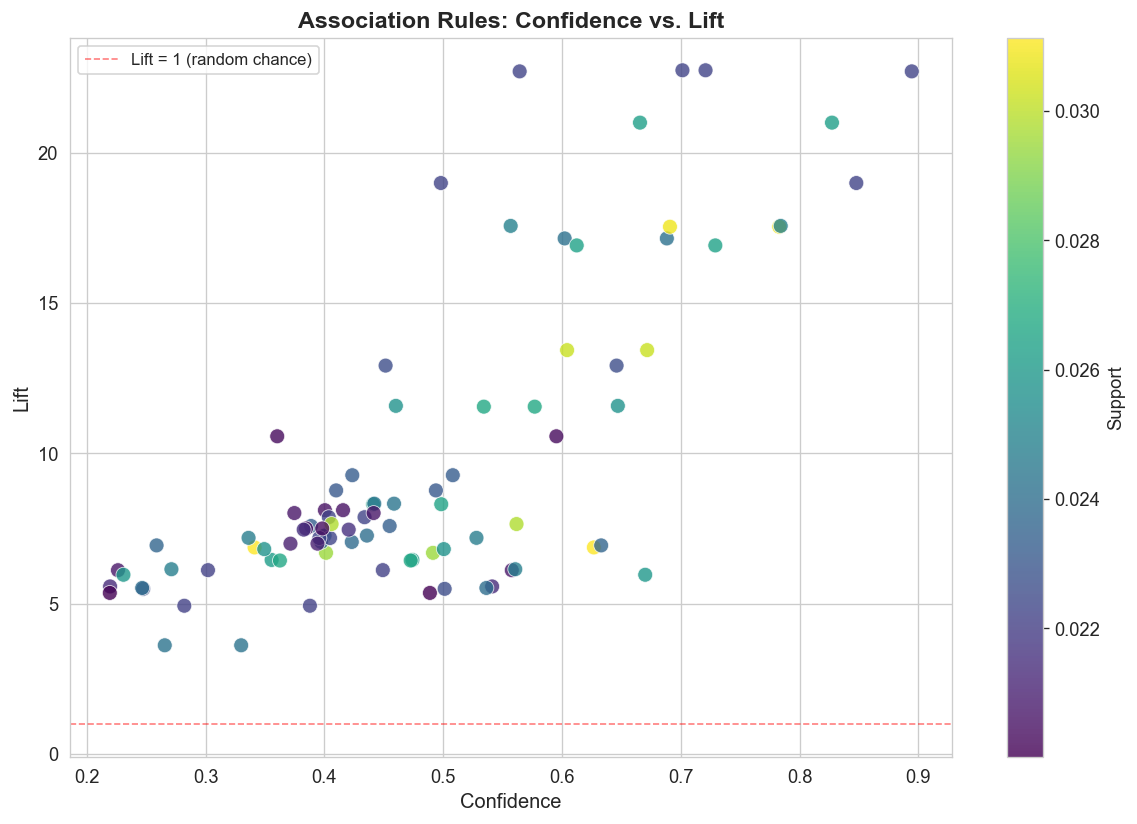

In [15]:
# Visualization 1: Scatter plot — Confidence vs Lift
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(rules["confidence"], rules["lift"],
                     c=rules["support"], cmap="viridis",
                     s=80, alpha=0.8, edgecolors="white", linewidth=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Support", fontsize=11)

ax.set_xlabel("Confidence", fontsize=12)
ax.set_ylabel("Lift", fontsize=12)
ax.set_title("Association Rules: Confidence vs. Lift", fontsize=14, fontweight="bold")
ax.axhline(y=1, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Lift = 1 (random chance)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Finding:** All discovered rules have lift well above 1 (the lowest is ~3.6), indicating that every rule represents a genuine positive association — not just a byproduct of item popularity. The scatter shows a strong positive correlation between confidence and lift in this dataset, but with notable spread: some rules with moderate confidence (~0.5) have very high lift (>20), meaning they capture strong but less obvious relationships.

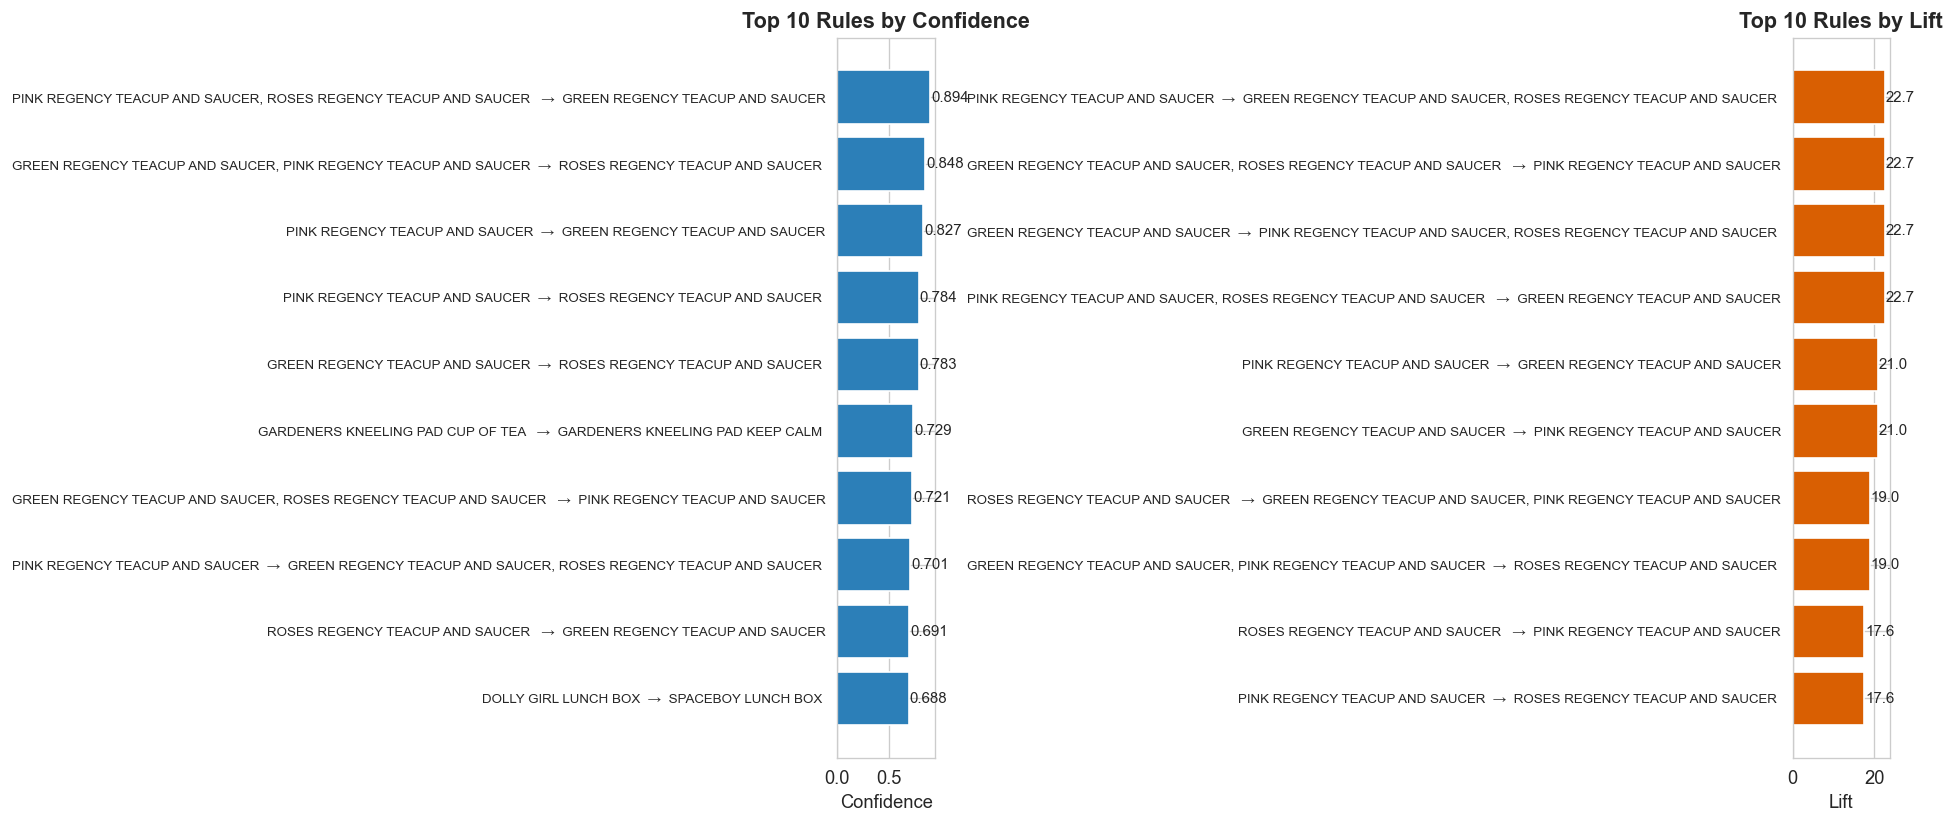


Overlap between top-10 confidence and top-10 lift: 6 of 10 rules
Unique to confidence ranking: 4 rules
Unique to lift ranking: 4 rules


In [16]:
# Visualization 2: Top 10 rules by Confidence vs Top 10 by Lift (side by side)
top_conf = rules.nlargest(10, "confidence")
top_lift = rules.nlargest(10, "lift")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Top by confidence
y_pos = range(len(top_conf))
conf_sorted = top_conf.sort_values("confidence", ascending=True)
ax1.barh(y_pos, conf_sorted["confidence"].values, color="#2c7fb8", edgecolor="white")
ax1.set_yticks(y_pos)
ax1.set_yticklabels(conf_sorted["rule_str"].values, fontsize=8)
ax1.set_xlabel("Confidence", fontsize=11)
ax1.set_title("Top 10 Rules by Confidence", fontsize=13, fontweight="bold")
for i, v in enumerate(conf_sorted["confidence"].values):
    ax1.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=9)

# Top by lift
lift_sorted = top_lift.sort_values("lift", ascending=True)
ax2.barh(y_pos, lift_sorted["lift"].values, color="#d95f02", edgecolor="white")
ax2.set_yticks(y_pos)
ax2.set_yticklabels(lift_sorted["rule_str"].values, fontsize=8)
ax2.set_xlabel("Lift", fontsize=11)
ax2.set_title("Top 10 Rules by Lift", fontsize=13, fontweight="bold")
for i, v in enumerate(lift_sorted["lift"].values):
    ax2.text(v + 0.2, i, f"{v:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Overlap analysis
overlap = set(top_conf.index) & set(top_lift.index)
print(f"\nOverlap between top-10 confidence and top-10 lift: {len(overlap)} of 10 rules")
print(f"Unique to confidence ranking: {10 - len(overlap)} rules")
print(f"Unique to lift ranking: {10 - len(overlap)} rules")

**Finding:** The top-10 lists by confidence and lift overlap by **6 rules** and diverge on **4**. Both rankings are dominated by the Regency Teacup product family (Green, Pink, Roses), which forms extremely strong associations (confidence up to 89%, lift up to 22.7x). The rules unique to the lift ranking tend to involve relationships where one item in the pair has lower overall popularity — precisely the kind of non-obvious association that lift is designed to surface.

In this particular dataset, the high-confidence rules are *also* high-lift because the frequent itemsets at 2% support already filter out trivially popular items. In datasets with more dominant bestsellers, the divergence between confidence and lift would be much larger.

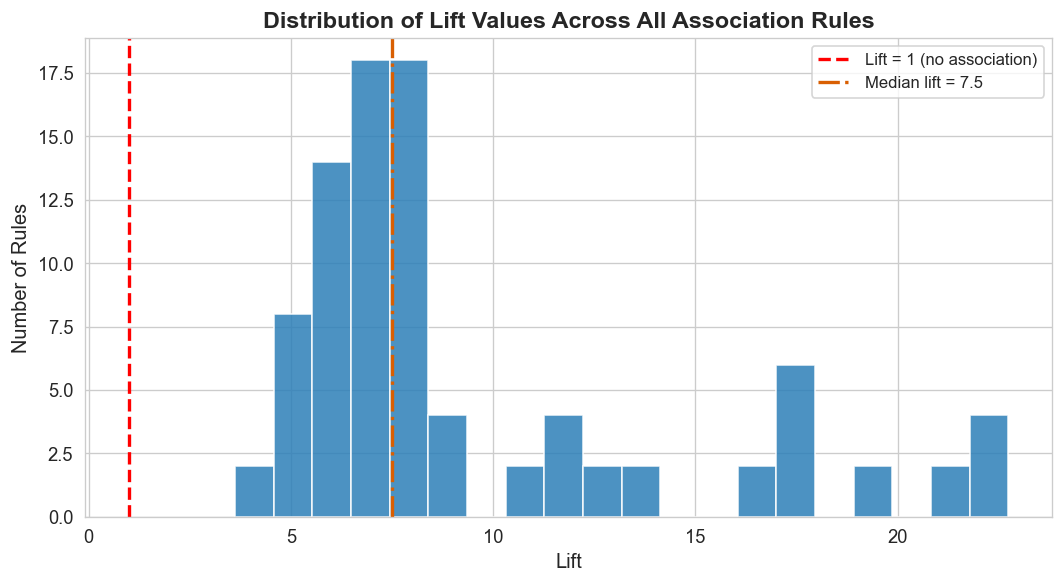

Rules with lift > 10: 26
Rules with lift > 15: 16
Rules with lift > 20: 6


In [17]:
# Visualization 3: Lift distribution
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(rules["lift"], bins=20, color="#2c7fb8", edgecolor="white", alpha=0.85)
ax.axvline(x=1, color="red", linewidth=2, linestyle="--", label="Lift = 1 (no association)")
ax.axvline(x=rules["lift"].median(), color="#d95f02", linewidth=2, linestyle="-.",
           label=f"Median lift = {rules['lift'].median():.1f}")
ax.set_xlabel("Lift", fontsize=12)
ax.set_ylabel("Number of Rules", fontsize=12)
ax.set_title("Distribution of Lift Values Across All Association Rules", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Rules with lift > 10: {(rules['lift'] > 10).sum()}")
print(f"Rules with lift > 15: {(rules['lift'] > 15).sum()}")
print(f"Rules with lift > 20: {(rules['lift'] > 20).sum()}")

**Finding:** The lift distribution is **right-skewed**, with most rules having lift between 3 and 8, but a cluster of exceptionally strong rules with lift exceeding 15–22. These high-lift rules all involve products from the same family (teacup sets, lunch bags). The fact that all rules are well above the lift=1 baseline confirms that the 2% support threshold effectively filters out noise, leaving only genuinely associated product pairs.

### RQ2 Summary

Confidence and lift are **correlated but not identical** metrics. In this dataset:
- **Confidence** tells us the reliability of a rule: "89% of customers who buy Pink + Roses teacups also buy the Green teacup."
- **Lift** tells us the strength relative to chance: "Buying the Pink teacup makes you 21x more likely to also buy the Green teacup than a random customer."

For a retailer, **lift is the more actionable metric** because it identifies product pairs with genuine affinity, regardless of baseline popularity. Confidence alone could be inflated by popular products that appear in many baskets.

---
## 6. RQ3: Sequential Patterns vs. Unordered Itemsets

So far, our analysis has treated each transaction as an isolated, unordered basket. RQ1 and RQ2 answered important questions about what products co-occur within single purchases. But our EDA revealed that this retailer has strong **repeat customers** — 4,338 unique customers made over 18,500 transactions across a full year. Many of these customers returned multiple times, and the seasonal volume spike suggests their purchasing behavior evolves over time.

This raises a natural question: **does the *order* in which customers buy products contain meaningful structure that basket analysis misses?** For example, if a customer buys a green teacup in January and returns for the matching pink teacup in March, that temporal relationship is invisible to association rules — both items never appeared in the same basket.

**Sequential pattern mining** (using the PrefixSpan algorithm) addresses this gap by analyzing ordered sequences of customer purchases over time. We construct customer purchase sequences by grouping transactions by `CustomerID`, ordering by `InvoiceDate`, and looking for recurring subsequences across customers.

In [18]:
# Build customer purchase sequences
top_items_seq = item_freq.head(200).index.tolist()
df_seq = df_clean[df_clean["Description"].isin(top_items_seq)].copy()
df_seq = df_seq.sort_values(["CustomerID", "InvoiceDate"])

sequences = []
for cid, cust_df in df_seq.groupby("CustomerID"):
    cust_seq = []
    for inv, inv_df in cust_df.groupby("InvoiceNo", sort=False):
        items = sorted(inv_df["Description"].unique().tolist())
        cust_seq.extend(items)
    if len(cust_seq) >= 2:
        sequences.append(cust_seq)

print(f"Customer sequences built: {len(sequences):,}")
print(f"Average sequence length:  {np.mean([len(s) for s in sequences]):.1f} items")
print(f"Median sequence length:   {np.median([len(s) for s in sequences]):.0f} items")
print(f"Customers with 2+ transactions: {len(sequences):,} (of {df_clean['CustomerID'].nunique():,} total)")

Customer sequences built: 3,903
Average sequence length:  31.2 items
Median sequence length:   13 items
Customers with 2+ transactions: 3,903 (of 4,338 total)


In [19]:
# Run PrefixSpan
ps = PrefixSpan(sequences)
ps.minlen = 2
ps.maxlen = 3

min_sup_count = int(len(sequences) * 0.03)
print(f"Minimum support count: {min_sup_count} ({min_sup_count/len(sequences)*100:.1f}% of customers)")

freq_seqs = ps.frequent(min_sup_count)
freq_seqs_sorted = sorted(freq_seqs, key=lambda x: x[0], reverse=True)

seq_2 = [(c, p) for c, p in freq_seqs_sorted if len(p) == 2]
seq_3 = [(c, p) for c, p in freq_seqs_sorted if len(p) == 3]

print(f"\nTotal sequential patterns: {len(freq_seqs_sorted):,}")
print(f"  Length-2 patterns: {len(seq_2):,}")
print(f"  Length-3 patterns: {len(seq_3):,}")

Minimum support count: 117 (3.0% of customers)



Total sequential patterns: 1,382
  Length-2 patterns: 907
  Length-3 patterns: 475


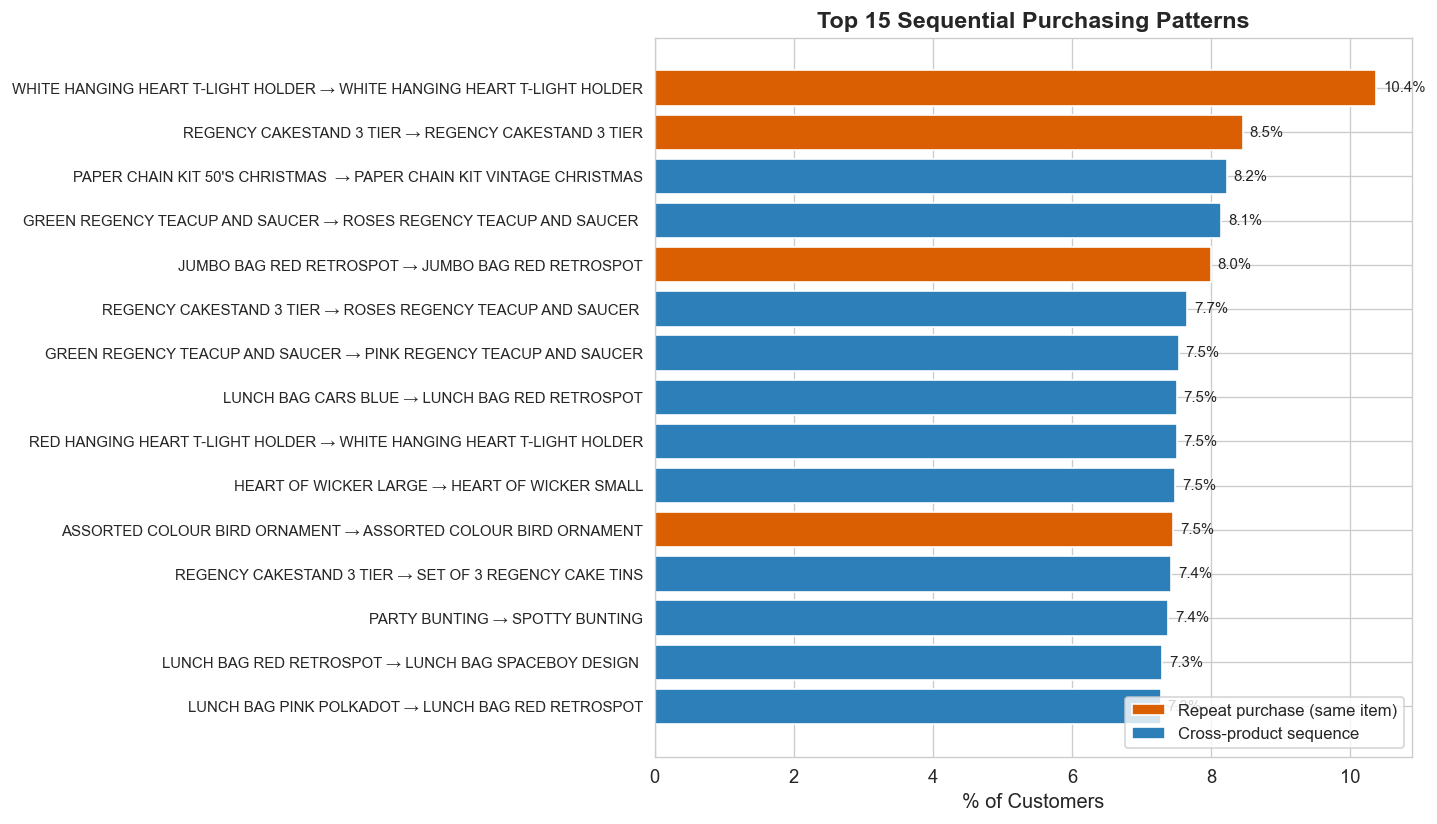

In [20]:
# Visualization 1: Top 15 sequential patterns
top_seqs = freq_seqs_sorted[:15]
labels = [" → ".join(p) for _, p in top_seqs]
counts = [c for c, _ in top_seqs]
pcts = [c / len(sequences) * 100 for c in counts]

fig, ax = plt.subplots(figsize=(12, 7))

# Color by pattern type
colors = []
for _, p in top_seqs:
    if p[0] == p[-1]:  # repeat purchase
        colors.append("#d95f02")
    else:
        colors.append("#2c7fb8")

bars = ax.barh(range(len(labels)), pcts[::-1], color=colors[::-1], edgecolor="white")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels[::-1], fontsize=9)
ax.set_xlabel("% of Customers", fontsize=12)
ax.set_title("Top 15 Sequential Purchasing Patterns", fontsize=14, fontweight="bold")

for i, v in enumerate(pcts[::-1]):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#d95f02", label="Repeat purchase (same item)"),
                   Patch(facecolor="#2c7fb8", label="Cross-product sequence")]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right")

plt.tight_layout()
plt.show()

**Finding:** The sequential patterns reveal two distinct types of temporal purchasing behavior:

1. **Repeat purchases** (orange bars): The most common pattern is customers re-buying the same item across different transactions. The "White Hanging Heart T-Light Holder" is repurchased by **10.4%** of customers. This represents customer loyalty or consumable replenishment — a signal completely invisible to unordered basket analysis.

2. **Cross-product sequences** (blue bars): These capture temporal "journeys" between related products. For example:
   - *Paper Chain Kit 50's Christmas → Paper Chain Kit Vintage Christmas* (8.2%): customers buying one seasonal decoration tend to buy the complementary style later.
   - *Green Regency Teacup → Roses Regency Teacup* (8.1%): customers collect pieces from the same product family over multiple visits.
   - *Red Hanging Heart T-Light Holder → White Hanging Heart T-Light Holder* (7.5%): customers who buy one color variant return for another.

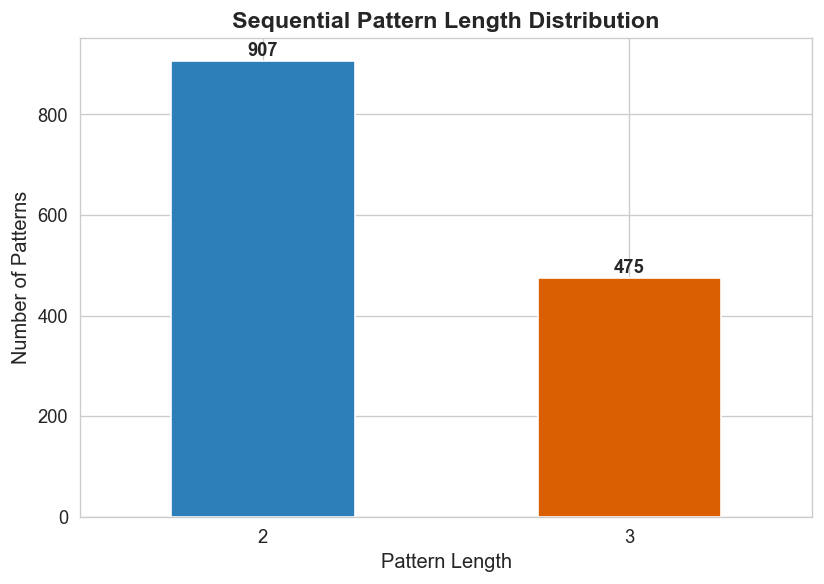

In [21]:
# Visualization 2: Sequential pattern length distribution
all_lengths = [len(p) for _, p in freq_seqs_sorted]
length_counts = pd.Series(all_lengths).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
length_counts.plot(kind="bar", ax=ax, color=["#2c7fb8", "#d95f02"], edgecolor="white")
ax.set_xlabel("Pattern Length", fontsize=12)
ax.set_ylabel("Number of Patterns", fontsize=12)
ax.set_title("Sequential Pattern Length Distribution", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=0)

for i, v in enumerate(length_counts.values):
    ax.text(i, v + 10, str(v), ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

**Finding:** PrefixSpan discovered **907 length-2 patterns** and **475 length-3 patterns** at 3% customer support. The abundance of length-3 patterns is particularly noteworthy — these represent purchasing journeys spanning three products across multiple transactions (e.g., *Green Teacup → Pink Teacup → Roses Teacup*). This three-step sequential structure is something that standard association rule mining **cannot represent**, since association rules only model within-transaction co-occurrence.

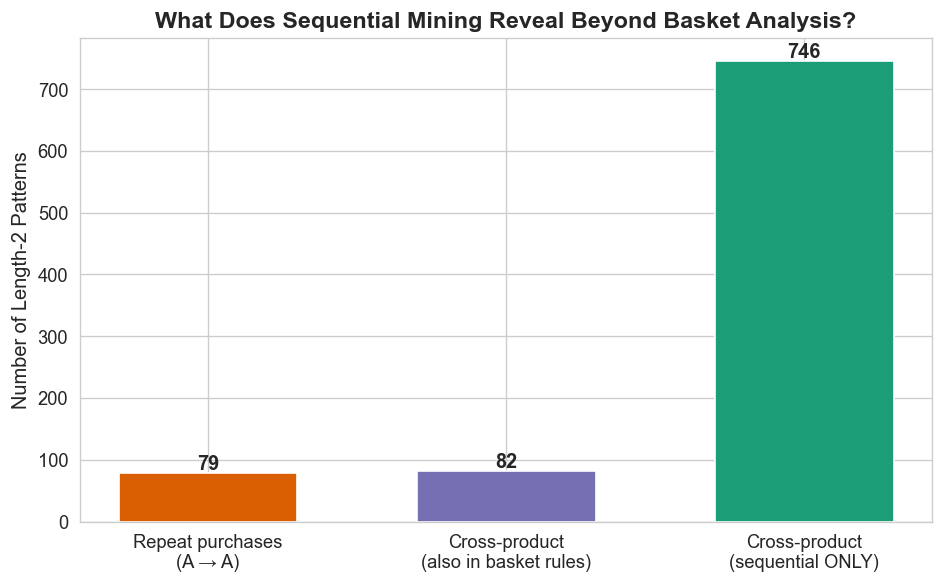

Total length-2 sequential patterns: 907
  Repeat purchases (A → A):         79 (8.7%)
  Cross-product (also in baskets):   82 (9.0%)
  Cross-product (sequential ONLY):   746 (82.2%)


In [22]:
# Visualization 3: Comparison — what sequential mining reveals that basket analysis cannot

# Identify repeat-purchase patterns (A → A) — inherently sequential
repeat_patterns = [(c, p) for c, p in seq_2 if p[0] == p[1]]
cross_patterns = [(c, p) for c, p in seq_2 if p[0] != p[1]]

# Categorize cross-product patterns
# Check which cross-product pairs also appear as frequent co-occurring itemsets
fi_pairs = fi_work[fi_work["length"] == 2]["itemsets"].apply(lambda x: frozenset(x)).tolist()

shared = 0
sequential_only = 0
for c, p in cross_patterns:
    pair_set = frozenset(p)
    if pair_set in fi_pairs:
        shared += 1
    else:
        sequential_only += 1

categories = ["Repeat purchases\n(A → A)", "Cross-product\n(also in basket rules)", "Cross-product\n(sequential ONLY)"]
values = [len(repeat_patterns), shared, sequential_only]
colors = ["#d95f02", "#7570b3", "#1b9e77"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(categories, values, color=colors, edgecolor="white", width=0.6)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha="center", fontsize=12, fontweight="bold")

ax.set_ylabel("Number of Length-2 Patterns", fontsize=12)
ax.set_title("What Does Sequential Mining Reveal Beyond Basket Analysis?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Total length-2 sequential patterns: {len(seq_2)}")
print(f"  Repeat purchases (A → A):         {len(repeat_patterns)} ({len(repeat_patterns)/len(seq_2)*100:.1f}%)")
print(f"  Cross-product (also in baskets):   {shared} ({shared/len(seq_2)*100:.1f}%)")
print(f"  Cross-product (sequential ONLY):   {sequential_only} ({sequential_only/len(seq_2)*100:.1f}%)")

**Finding:** This is the core result for RQ3. Of the **907 length-2 sequential patterns**:

- **79 (8.7%) are repeat purchases (A → A)** — entirely unique to sequential mining. Standard basket analysis cannot detect that a customer buys the same product again in a later transaction. These patterns represent customer loyalty and replenishment behavior.
- **82 (9.0%) are cross-product patterns also found in basket rules** — co-purchases that happen both within single transactions and across transactions.
- **746 (82.2%) are cross-product patterns unique to sequential mining** — relationships that *only* manifest across separate shopping trips. For example, a customer buys a cakestand in one visit and returns for matching teacups — this temporal dependency is invisible to within-basket analysis.

The most striking result is that **over 82% of the sequential patterns have no counterpart in the association rules**. This demonstrates that sequential pattern mining provides a **fundamentally different and complementary view** of customer behavior. It captures the temporal dimension — repeat purchasing, product exploration journeys, and delayed complementary purchases — that association rules cannot represent.

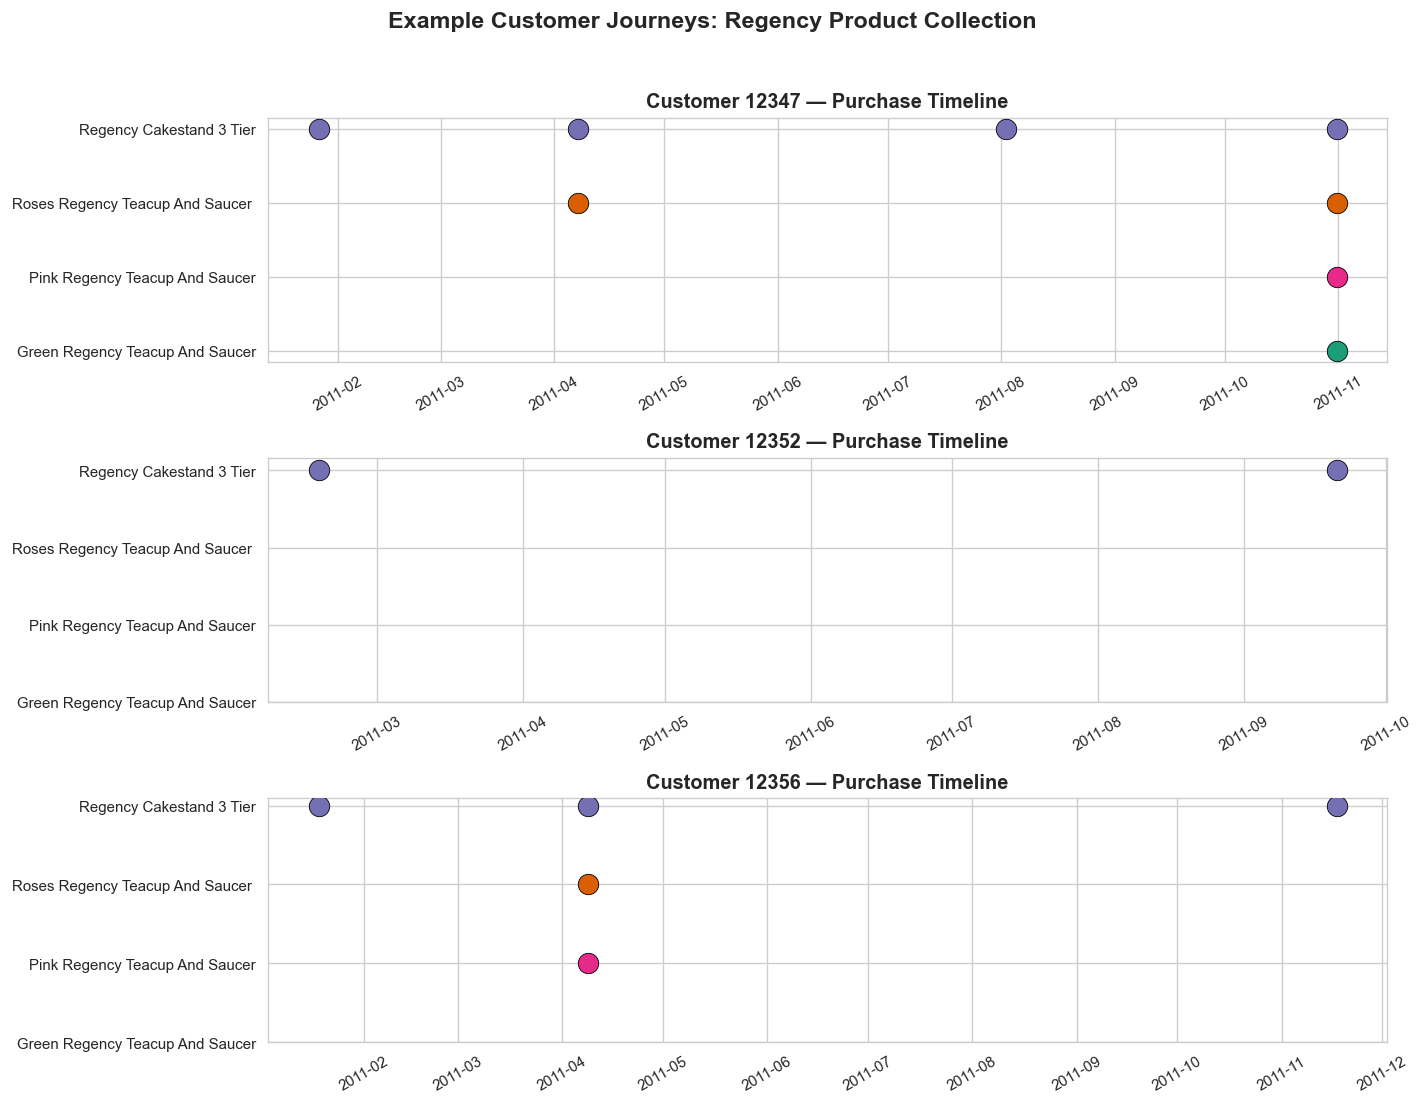

In [23]:
# Visualization 4: Example customer journeys — making sequential patterns concrete

# Find a few interesting customers who exhibit the teacup collection pattern
teacup_items = ["GREEN REGENCY TEACUP AND SAUCER", "PINK REGENCY TEACUP AND SAUCER",
                "ROSES REGENCY TEACUP AND SAUCER ", "REGENCY CAKESTAND 3 TIER"]

df_teacup = df_clean[df_clean["Description"].isin(teacup_items)].copy()
df_teacup = df_teacup.sort_values(["CustomerID", "InvoiceDate"])

# Find customers who bought these items across multiple dates
cust_dates = df_teacup.groupby("CustomerID")["InvoiceDate"].apply(lambda x: x.dt.date.nunique())
multi_date_custs = cust_dates[cust_dates >= 2].index.tolist()[:3]

if len(multi_date_custs) > 0:
    fig, axes = plt.subplots(len(multi_date_custs), 1, figsize=(12, 3 * len(multi_date_custs)))
    if len(multi_date_custs) == 1:
        axes = [axes]

    item_colors = {"GREEN REGENCY TEACUP AND SAUCER": "#1b9e77",
                   "PINK REGENCY TEACUP AND SAUCER": "#e7298a",
                   "ROSES REGENCY TEACUP AND SAUCER ": "#d95f02",
                   "REGENCY CAKESTAND 3 TIER": "#7570b3"}

    for idx, (cid, ax) in enumerate(zip(multi_date_custs, axes)):
        cust_data = df_teacup[df_teacup["CustomerID"] == cid].copy()
        cust_data = cust_data.drop_duplicates(subset=["InvoiceNo", "Description"])

        for _, row in cust_data.iterrows():
            color = item_colors.get(row["Description"], "gray")
            y_pos = list(item_colors.keys()).index(row["Description"]) if row["Description"] in item_colors else 0
            ax.scatter(row["InvoiceDate"], y_pos, color=color, s=150, zorder=5, edgecolors="black", linewidth=0.5)

        ax.set_yticks(range(len(item_colors)))
        ax.set_yticklabels([k.title() for k in item_colors.keys()], fontsize=9)
        ax.set_title(f"Customer {int(cid)} — Purchase Timeline", fontsize=12, fontweight="bold")
        ax.tick_params(axis="x", rotation=30, labelsize=9)

    plt.suptitle("Example Customer Journeys: Regency Product Collection",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No multi-date customers found for this product set.")

**Takeaway:** The customer journey timelines make the sequential patterns concrete. Individual customers can be seen collecting pieces from the Regency product family across multiple shopping sessions — buying the cakestand in one visit, returning for the green teacup weeks later, then adding the pink and roses variants. This type of progressive product exploration is a valuable signal for **targeted recommendations** ("You bought the green teacup — consider the matching pink and roses sets") that standard basket analysis would not suggest.

### RQ3 Summary

Sequential pattern mining with PrefixSpan reveals **1,382 frequent patterns** across customer purchase histories, including:

1. **Repeat purchases** — the most common pattern type, showing customers who repurchase the same product across visits. This is invisible to association rules.
2. **Cross-product temporal sequences** — hundreds of patterns that capture products bought in succession across different transactions. Many of these do not appear as co-occurring pairs in any single basket.
3. **Multi-step purchase journeys** (length-3 patterns) — 475 three-item sequences that model longer purchasing trajectories, such as collecting items from the same product family over time.

**Conclusion:** Sequential mining and association rules are **complementary, not competing** techniques. Association rules identify what goes together in a single basket; sequential mining identifies what follows what over time.

---
## 7. Conclusions

### The Big Picture

This project set out to answer a simple question: **what can the purchasing data from an online retailer tell us about how customers actually behave?** Across three progressively deeper analyses, a clear picture emerged — one that no single technique could have revealed on its own.

**RQ1 showed us that parameter choices determine what we can see.** The support threshold is not a minor tuning knob — it is a gate that controls whether multi-item associations are discoverable at all. At 5% support, we see only popular individual products; at 1%, we find 914 itemsets including 70+ triplets. The lesson is that a practitioner who sets the threshold too high will conclude, incorrectly, that no meaningful co-purchase patterns exist.

**RQ2 showed us that not all metrics agree on what matters.** Confidence and lift are correlated, but they surface different rules in their top-10 rankings. Lift proved more informative because it corrects for item popularity — it identifies product pairs with genuine affinity, not just pairs involving bestsellers. The Regency Teacup family stood out as the strongest association in the dataset (lift > 22), a finding that would power concrete product bundling decisions.

**RQ3 revealed a dimension of behavior that basket analysis cannot see.** This was the most striking finding: **82% of sequential patterns had no counterpart in the association rules.** Customers do not just buy things together in one visit — they return over time, repurchase favorites, and progressively explore product families across multiple shopping sessions. This temporal structure is invisible to traditional basket analysis and represents a fundamentally different layer of customer understanding.

### Practical Implications

If you were running this retailer's data team, here is what these findings would mean in practice:

- **For product recommendations:** Use association rules (with lift as the primary metric) for *within-session* suggestions ("You might also like..."), and sequential patterns for *cross-session* recommendations ("Based on your purchase history, you might want to try..."). These are two different recommendation engines, not one.
- **For inventory and merchandising:** The Regency Teacup family shows that customers collect product variants over time. Ensuring all variants are in stock simultaneously — and displaying them as a collection — could accelerate this natural collecting behavior.
- **For parameter tuning:** Start with a low support threshold (1-2%) and use lift to filter the resulting rules, rather than setting a high threshold and hoping meaningful patterns survive. The data's sparsity means that interesting relationships live in the long tail.
- **For customer retention:** The repeat-purchase patterns identified by PrefixSpan are direct signals for retention campaigns. A customer who bought the White Hanging Heart T-Light Holder has a 10.4% chance of buying it again — a trigger for a well-timed re-engagement email.

### Limitations

- **Single retailer:** All data comes from one UK-based online gift retailer, limiting generalizability to other markets or product categories (e.g., groceries would show different patterns).
- **Sparsity:** Even at 1% support, many potentially meaningful patterns in niche products remain undiscovered. The long tail is long.
- **Product granularity:** We used the top 500 products for basket analysis and top 200 for sequential analysis due to computational constraints. Including all 3,665 products could reveal additional long-tail patterns.
- **Temporal resolution:** PrefixSpan treats the entire customer history as one flat sequence. Finer windowing (e.g., 30-day sessions) could capture more nuanced temporal behavior and distinguish "bought the same day" from "bought months apart."

### Future Work

- **Customer segmentation:** Apply clustering to identify distinct customer types (e.g., one-time buyers vs. repeat collectors) and mine patterns within each segment — the same product pair may be meaningful for one segment but not another.
- **Seasonal patterns:** Analyze how association rules change across months. The November purchasing spike likely contains Christmas-specific co-purchases (e.g., gift sets) that do not appear in the annual aggregate.
- **Recommendation engine evaluation:** Use the discovered sequential patterns to build a temporal recommendation engine and evaluate it with standard metrics (precision, recall, NDCG) on a held-out test set.
- **Statistical significance testing:** Apply techniques like the chi-squared test or Fisher's exact test to validate that discovered associations are statistically significant, not just artifacts of support thresholds.